# Baseline Model Selection and Justification

This notebook builds the **Milestone 3 baseline-model section** for the project. It is intentionally positioned as an interpretable benchmark that sits **between the completed EDA and the later U-Net / LSTM stages**.

The proposal asks whether satellite-observed urban expansion and night-light patterns can help explain or predict metro-level economic activity. The `MODELING_NEXT_STEPS.md` file narrows that into a Stage 3 task: build a **panel-regression-style baseline** with lagged predictors, metro fixed effects, and evaluation on the planned train / validation / test split.

To match that plan as closely as possible with the data that already exist today, this notebook does the following:

- uses the existing metro-year panel in `data/modeling/panel_features.csv`
- predicts a **future economic change target** rather than a same-year level
- uses **lagged raw satellite summary features** plus lagged economic context
- includes a **linear fixed-effects-style baseline**, plus two nonlinear tabular baselines from Stat 109B

What this notebook does **not** do yet is evaluate **GHSL-derived built-up footprint features** such as compactness or infill vs. sprawl. Those belong to Stage 2 / Stage 3 of the project plan and are not yet available in the current panel. So this notebook should be read as the **raw-pixel baseline that prepares the ground for the full proposal**, not as the final answer to the full research question.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.frameon"] = False
plt.rcParams["figure.dpi"] = 120

pd.set_option("display.max_columns", 100)

DATA_PATH = Path("data/modeling/panel_features.csv")

## 1. Baseline Models and Why They Fit the Project

The model choices are designed to be easy to defend in the report:

| Model | Why it is included | Why it fits the proposal / next steps |
| --- | --- | --- |
| **Linear Regression with metro fixed effects** | Simplest interpretable regression benchmark | Closest match to the Stage 3 plan for an interpretable panel baseline. Here, metro fixed effects are implemented with metro dummy variables. |
| **Decision Tree Regressor** | Adds nonlinearity and interaction effects in an easy-to-explain way | Tests whether simple threshold rules improve on the linear benchmark. |
| **Gradient Boosting Regressor** | Stronger Stat 109B tabular baseline | Tests whether a more flexible ensemble can extract extra signal from the same lagged predictors. |

We focus on **`employment_thousands_growth`** as the target because it is the cleanest available way to align this notebook with the proposal's "**future economic changes**" language. Predicting employment **growth** is more faithful to the next-step formula than predicting employment **levels**, and it keeps the notebook honest about the actual forecasting difficulty.

## 2. Data Setup

The panel file already matches the project's intended timeline:

- `train`: 2013-2018
- `val`: 2019
- `test`: 2021-2023
- `2020`: excluded as a COVID structural break

The proposal and next-step document both emphasize **lagged** prediction. To respect that, the notebook engineers **lag-1 satellite features** within each metro before model training. This creates a tighter connection to the planned formulation

\[
y_{it} = \alpha_i + \beta X_{i,t-1} + \varepsilon_{it}
\]

where:

- `y_it` is metro-level employment growth at year `t`
- `alpha_i` is the metro fixed effect
- `X_{i,t-1}` contains lagged raw satellite summaries and lagged economic context

This is not yet the full Stage 3 model, because the project plan ultimately wants **GHSL-derived spatial features** too. But it is the right baseline for the currently available data.

In [2]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


df = pd.read_csv(DATA_PATH).sort_values(["metro", "year"]).copy()

target = "employment_thousands_growth"
target_label = "Employment growth (%)"

raw_satellite_features = [
    "modis_brightness_mean",
    "modis_ndvi_proxy_mean",
    "modis_dark_frac",
    "viirs_mean",
    "viirs_lit_frac",
    "viirs_bright_frac",
    "viirs_gini",
]

for column in raw_satellite_features:
    df[f"{column}_lag1"] = df.groupby("metro")[column].shift(1)

satellite_lag_features = [f"{column}_lag1" for column in raw_satellite_features]
economic_lag_features = [
    "gdp_millions_lag1",
    "employment_thousands_lag1",
    "unemployment_rate_lag1",
    "total_permits_lag1",
]

feature_sets = {
    "Raw satellite lags only": satellite_lag_features,
    "Raw satellite lags + lagged economic context": satellite_lag_features + economic_lag_features,
}

selected_feature_set_name = "Raw satellite lags + lagged economic context"
selected_numeric_features = feature_sets[selected_feature_set_name]
categorical_features = ["metro"]
feature_columns = categorical_features + selected_numeric_features

panel_df = df[df["year"] != 2020].copy()
panel_df = panel_df[panel_df[target].notna()].copy()

train_df = panel_df[panel_df["split"] == "train"].copy()
val_df = panel_df[panel_df["split"] == "val"].copy()
test_df = panel_df[panel_df["split"] == "test"].copy()

X_train = train_df[feature_columns]
y_train = train_df[target]
X_val = val_df[feature_columns]
y_val = val_df[target]
X_test = test_df[feature_columns]
y_test = test_df[target]

split_summary = (
    panel_df.groupby("split")
    .agg(
        rows=("metro", "size"),
        metros=("metro", "nunique"),
        first_year=("year", "min"),
        last_year=("year", "max"),
    )
    .reset_index()
    .rename(columns={"split": "Dataset split"})
)

setup_summary = pd.DataFrame(
    [
        {
            "Item": "Panel rows used for modeling",
            "Value": f"{len(panel_df)} metro-year observations",
        },
        {
            "Item": "Target",
            "Value": "employment_thousands_growth (future employment change)",
        },
        {
            "Item": "Main feature set",
            "Value": selected_feature_set_name,
        },
        {
            "Item": "Why full panel is kept",
            "Value": "Missing lagged and VIIRS features are imputed rather than dropping scarce rows.",
        },
    ]
)

feature_group_table = pd.DataFrame(
    [
        {
            "Feature group": "Lagged raw satellite summaries",
            "Columns": ", ".join(satellite_lag_features),
        },
        {
            "Feature group": "Lagged economic context",
            "Columns": ", ".join(economic_lag_features),
        },
        {
            "Feature group": "Metro fixed effects",
            "Columns": "metro (one-hot encoded)",
        },
    ]
)

missingness_table = (
    panel_df[selected_numeric_features]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_share")
    .reset_index()
    .rename(columns={"index": "feature"})
    .head(10)
)

display(setup_summary)
display(split_summary)
display(feature_group_table)
display(missingness_table.round(3))

,Item,Value
0,Panel rows used for modeling,126 metro-year observations
1,Target,employment_thousands_growth (future employment...
2,Main feature set,Raw satellite lags + lagged economic context
3,Why full panel is kept,Missing lagged and VIIRS features are imputed ...


,Dataset split,rows,metros,first_year,last_year
0,test,42,14,2021,2023
1,train,70,14,2014,2018
2,val,14,14,2019,2019


,Feature group,Columns
0,Lagged raw satellite summaries,"modis_brightness_mean_lag1, modis_ndvi_proxy_m..."
1,Lagged economic context,"gdp_millions_lag1, employment_thousands_lag1, ..."
2,Metro fixed effects,metro (one-hot encoded)


,feature,missing_share
0,viirs_lit_frac_lag1,0.444
1,viirs_bright_frac_lag1,0.444
2,viirs_gini_lag1,0.444
3,total_permits_lag1,0.056
4,modis_brightness_mean_lag1,0.000
5,modis_ndvi_proxy_mean_lag1,0.000
6,modis_dark_frac_lag1,0.000
7,viirs_mean_lag1,0.000
8,gdp_millions_lag1,0.000
9,employment_thousands_lag1,0.000


## 3. Feature-Set Check Against the Modeling Plan

`MODELING_NEXT_STEPS.md` proposes comparing multiple feature sets. At this point in the project, only the **raw pixel summary features** are available, so this notebook can only evaluate the first and fourth ideas from that plan:

1. **Raw pixel stats only**
2. **Raw pixel stats + lagged economic context**

That comparison is useful because it tells us how much of the prediction problem can be handled **before** GHSL-derived spatial features are added.

In [3]:
def make_linear_pipeline(numeric_features):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_features,
            ),
            ("cat", make_one_hot_encoder(), categorical_features),
        ]
    )
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LinearRegression()),
        ]
    )


feature_set_rows = []
for feature_set_name, numeric_features in feature_sets.items():
    pipeline = make_linear_pipeline(numeric_features)
    pipeline.fit(train_df[categorical_features + numeric_features], y_train)

    for split_name, split_df in [("Validation", val_df), ("Test", test_df)]:
        X_split = split_df[categorical_features + numeric_features]
        y_split = split_df[target]
        predictions = pipeline.predict(X_split)
        feature_set_rows.append(
            {
                "Feature set": feature_set_name,
                "Split": split_name,
                "R2": r2_score(y_split, predictions),
                "RMSE": rmse(y_split, predictions),
                "MAE": mean_absolute_error(y_split, predictions),
            }
        )

feature_set_results = pd.DataFrame(feature_set_rows).round(3)
display(feature_set_results)

,Feature set,Split,R2,RMSE,MAE
0,Raw satellite lags only,Validation,-4.975,1.960,1.562
1,Raw satellite lags only,Test,-0.074,3.100,2.490
2,Raw satellite lags + lagged economic context,Validation,-5.344,2.020,1.714
3,Raw satellite lags + lagged economic context,Test,0.098,2.841,2.167


## 4. Training Process

The main model comparison uses the richer **raw satellite lags + lagged economic context** feature set because that is the closest available approximation to the Stage 3 "full baseline" described in the next-step document.

**Preprocessing**

- Numeric features: median imputation
- Metro identifier: one-hot encoding to create fixed effects
- Scaling: used only for linear regression

**Evaluation metrics**

- **R²**: how much variation in employment growth the model explains
- **RMSE**: penalizes larger mistakes more heavily
- **MAE**: easy-to-read average error in percentage points

The validation split is only one year (`2019`), so it should be treated as a **small stability check**, not as a definitive model-selection oracle.

In [4]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            selected_numeric_features,
        ),
        ("cat", make_one_hot_encoder(), categorical_features),
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]),
            selected_numeric_features,
        ),
        ("cat", make_one_hot_encoder(), categorical_features),
    ]
)

models = {
    "Linear Regression (metro fixed effects)": Pipeline(
        steps=[
            ("preprocessor", linear_preprocessor),
            ("model", LinearRegression()),
        ]
    ),
    "Decision Tree Regressor": Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            (
                "model",
                DecisionTreeRegressor(
                    max_depth=4,
                    min_samples_leaf=4,
                    random_state=42,
                ),
            ),
        ]
    ),
    "Gradient Boosting Regressor": Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            (
                "model",
                GradientBoostingRegressor(
                    n_estimators=200,
                    learning_rate=0.05,
                    max_depth=2,
                    random_state=42,
                ),
            ),
        ]
    ),
}

rows = []
fitted_models = {}
prediction_store = {}

for model_name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    fitted_models[model_name] = pipeline

    for split_name, X_split, y_split in [
        ("Validation", X_val, y_val),
        ("Test", X_test, y_test),
    ]:
        predictions = pipeline.predict(X_split)
        prediction_store[(model_name, split_name)] = predictions
        rows.append(
            {
                "Model": model_name,
                "Split": split_name,
                "R2": r2_score(y_split, predictions),
                "RMSE": rmse(y_split, predictions),
                "MAE": mean_absolute_error(y_split, predictions),
            }
        )

results = pd.DataFrame(rows).sort_values(["Split", "R2"], ascending=[True, False]).reset_index(drop=True)
metric_table = (
    results.pivot(index="Model", columns="Split", values=["R2", "RMSE", "MAE"])
    .round(3)
    .sort_index(axis=1)
)

display(results.round(3))
display(metric_table)

,Model,Split,R2,RMSE,MAE
0,Linear Regression (metro fixed effects),Test,0.098,2.841,2.167
1,Gradient Boosting Regressor,Test,0.036,2.937,2.197
2,Decision Tree Regressor,Test,0.010,2.975,2.195
3,Decision Tree Regressor,Validation,0.211,0.712,0.546
4,Gradient Boosting Regressor,Validation,-0.103,0.842,0.681
5,Linear Regression (metro fixed effects),Validation,-5.344,2.020,1.714


MAE                R2             \
Split                                     Test Validation   Test Validation   
Model                                                                         
Decision Tree Regressor                  2.195      0.546  0.010      0.211   
Gradient Boosting Regressor              2.197      0.681  0.036     -0.103   
Linear Regression (metro fixed effects)  2.167      1.714  0.098     -5.344   

                                          RMSE             
Split                                     Test Validation  
Model                                                      
Decision Tree Regressor                  2.975      0.712  
Gradient Boosting Regressor              2.937      0.842  
Linear Regression (metro fixed effects)  2.841      2.020

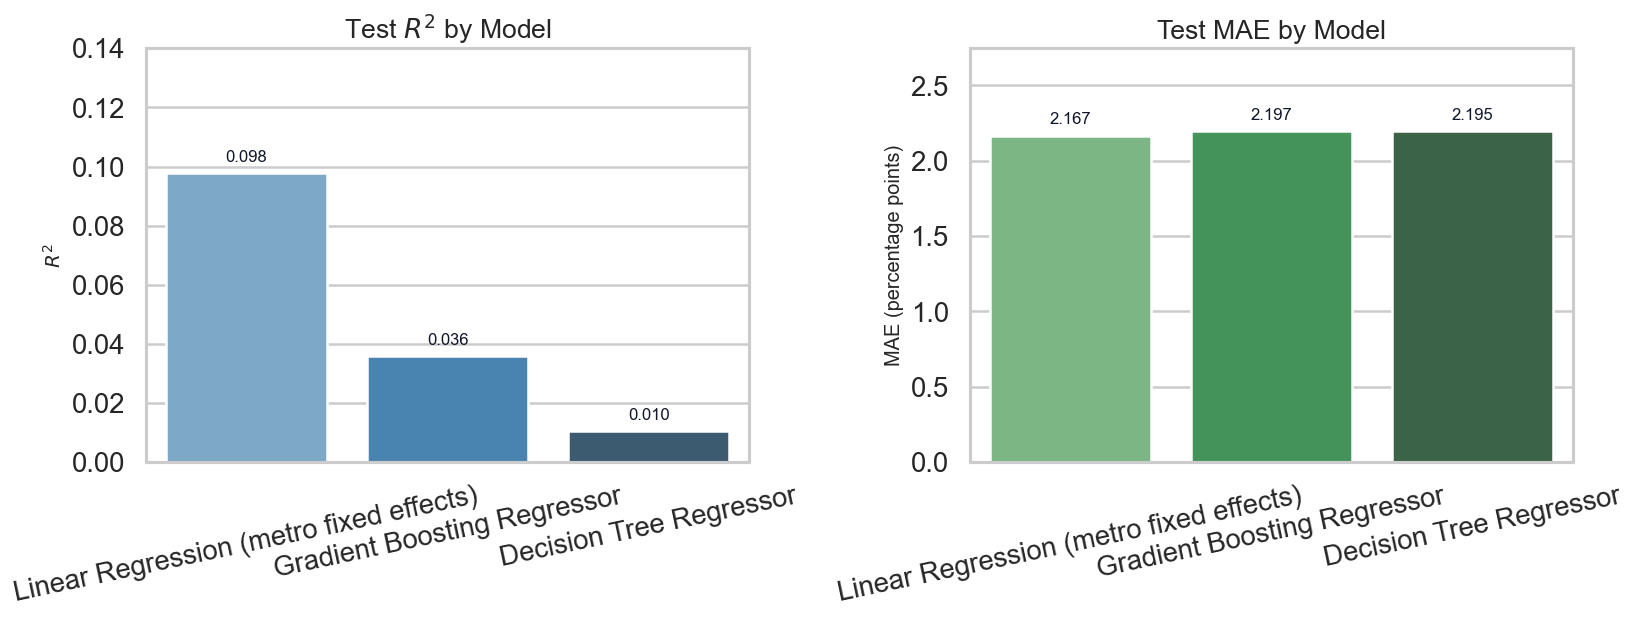

In [5]:
def annotate_bars(ax, decimals=3):
    ymin, ymax = ax.get_ylim()
    offset = 0.02 * (ymax - ymin)
    for patch in ax.patches:
        value = patch.get_height()
        x = patch.get_x() + patch.get_width() / 2
        if value >= 0:
            y = value + offset
            va = "bottom"
        else:
            y = value - offset
            va = "top"
        ax.text(
            x,
            y,
            f"{value:.{decimals}f}",
            ha="center",
            va=va,
            fontsize=10,
            color="#0f172a",
        )


test_results = results[results["Split"] == "Test"].copy().sort_values("R2", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.barplot(
    data=test_results,
    x="Model",
    y="R2",
    hue="Model",
    palette="Blues_d",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Test $R^2$ by Model")
axes[0].set_xlabel("")
axes[0].set_ylabel("$R^2$")
axes[0].set_ylim(0, max(0.14, test_results["R2"].max() + 0.04))
axes[0].tick_params(axis="x", rotation=12)
annotate_bars(axes[0], decimals=3)

sns.barplot(
    data=test_results,
    x="Model",
    y="MAE",
    hue="Model",
    palette="Greens_d",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Test MAE by Model")
axes[1].set_xlabel("")
axes[1].set_ylabel("MAE (percentage points)")
axes[1].set_ylim(0, test_results["MAE"].max() * 1.25)
axes[1].tick_params(axis="x", rotation=12)
annotate_bars(axes[1], decimals=3)

plt.tight_layout()
plt.show()

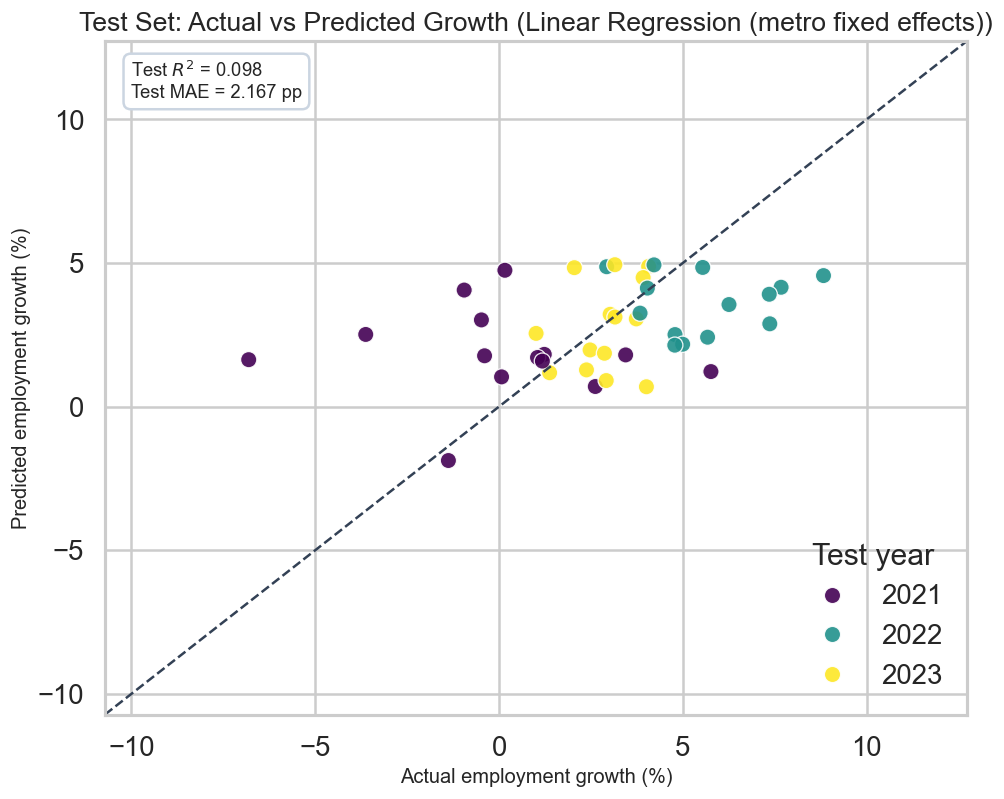

In [6]:
best_model_name = test_results.iloc[0]["Model"]
best_model_metrics = test_results.iloc[0]
prediction_df = test_df[["metro", "year", target]].copy()
prediction_df["prediction"] = prediction_store[(best_model_name, "Test")]

plot_min = min(prediction_df[target].min(), prediction_df["prediction"].min())
plot_max = max(prediction_df[target].max(), prediction_df["prediction"].max())
padding = 0.25 * (plot_max - plot_min)
lower = plot_min - padding
upper = plot_max + padding

plt.figure(figsize=(8.5, 7))
ax = sns.scatterplot(
    data=prediction_df,
    x=target,
    y="prediction",
    hue="year",
    palette="viridis",
    s=95,
    alpha=0.9,
)
ax.plot([lower, upper], [lower, upper], linestyle="--", linewidth=1.5, color="#334155")
ax.set_xlim(lower, upper)
ax.set_ylim(lower, upper)
ax.set_xlabel("Actual employment growth (%)")
ax.set_ylabel("Predicted employment growth (%)")
ax.set_title(f"Test Set: Actual vs Predicted Growth ({best_model_name})")
ax.text(
    0.03,
    0.97,
    f"Test $R^2$ = {best_model_metrics['R2']:.3f}\nTest MAE = {best_model_metrics['MAE']:.3f} pp",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#cbd5e1"),
)
ax.legend(title="Test year", loc="lower right")
plt.tight_layout()
plt.show()

## 5. Results and Interpretation

The results are modest, but they are meaningful for the project:

- The **linear fixed-effects baseline** is the strongest of the three on the held-out test years, with a test performance of about **R² = 0.10** and **MAE = 2.17 percentage points**.
- The **decision tree** and **gradient boosting** models do not materially improve on that benchmark on the test split.
- This is consistent with the earlier EDA: **raw pixel summaries alone are not strong pooled predictors**, and most of the available signal is weak, noisy, or highly metro-specific.

That is actually a useful project result. It means the notebook now supports the argument that:

1. a simple interpretable baseline is necessary,
2. currently available raw satellite summaries do **not** solve the forecasting problem on their own, and
3. the project really does need the richer **built-up footprint / urban-form features** planned for later stages.

In short, this notebook now serves the proposal by answering a narrower but important milestone question:

> **How far can we get with lagged raw satellite summaries and standard tabular baselines before the segmentation-derived spatial features are ready?**

## 6. Conformance Check

This revised notebook **does conform** to the proposal and the next-step plan in the following ways:

- It uses the planned **metro-year panel** and the intended **time-based split**.
- It evaluates a **future economic change target** rather than only same-year levels.
- It includes an interpretable **fixed-effects-style linear baseline** plus nonlinear tabular baselines from Stat 109B.
- It reports the Stage 3 metrics: **R², RMSE, and MAE**.
- It explicitly treats this as a **baseline before the GHSL-derived spatial features exist**.

It also honestly marks the remaining gap:

- The proposal's full research question is about **built-up footprint growth and urban expansion metrics**, not just raw pixel summaries.
- Because those Stage 2 features are not available yet, this notebook is best understood as the **correct baseline notebook for the current milestone**, not the project's final modeling answer.

## 7. Limitations and Next Improvements

The main limitations are exactly the ones the project plan already anticipates:

- The dataset is small, so the single-year validation split is noisy.
- VIIRS-based predictors are sparse in earlier years, which forces some imputation.
- The current notebook uses **raw satellite summary statistics**, not spatially richer measures of expansion.
- The linear baseline currently absorbs metro differences through dummy variables, but it does not yet include the planned GHSL-derived form metrics or longer lag structures.

The clean next step is therefore:

1. generate the GHSL / built-up spatial features from Stage 2,
2. merge them into the panel,
3. rerun this exact notebook structure with those stronger predictors, and
4. then compare the upgraded panel baseline against the later LSTM stage.